# Credit Risk Analysis: Retail Mortgage Loans
## Markov Chain Model for Delinquency State Transitions, Time-To-Default, and Time-To-Prepayment

#### Antonio Melacini,  December 2025

## Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path # ensures compatibility of file path strings across Windows/Mac/Linux

We use the column/variable names, order, and data types from the `file_layout.xlsx` file found on the Freddie Mac SFLLD webpage.

In [ ]:
data = pd.read_csv(Path("data/processed/DTMC"))

## Define Credit States and Prep Data for Modeling

We define "default" as 90 or more days past due. This is not a perfect definition. There include some loans which were at some point 90+ days past due and later became current, although 90+ days past due still represents a serious deqliquency and is the definition used in BASEL regulation, so that is what we use for the sake of this project.

We assume that the states of a lender's credit can be represented as 
$$
S = \{\verb|Prepaid|, ~\verb|Current|,~ \verb|30 DPD|,~ \verb|60 DPD|,~\verb|Default| \}
$$
where DPD abbreviates "Days Past Due", "30 DPD" really represents 1 missed payment, and "60 DPD" really represents 2 missed payments.

We model the time evolution of a lender's state of credit as a discrete-time stochastic process $(X_t)_{t\in\mathbb{N}}\in S^\mathbb{N}$ where 
$$
X_t = (\text{credit state of lender at time }t)
$$
and we use the definition of the natural numbers $\mathbb{N}=\{1,2,3,\dots\}$.

We choose to model "Current", "30 DPD", "60 DPD", and "90+ DPD" as transient states, meaning we assume that once a lender is in one of these states, there is a chance that they will not return to that state infinitely often. We model "Prepaid" and "Default" as recurrent absorbing states, meaning that we assume that once a lender has prepaid or defaulted, they will forever be in that state - which is perhaps one of the most realistic assumptions we make.

Note: *prepayment* refers to *full prepayment* of the entire loan, not just the monthly payment.

In [ ]:
data = data.sort_values(["loan_sequence_number", "monthly_reporting_period"])
data.head(5)

,loan_sequence_number,monthly_reporting_period,deliq_num,loan_age,zero_balance_code
0,F16Q10000002,2016-04-01,0,0,<NA>
1,F16Q10000002,2016-05-01,0,1,<NA>
2,F16Q10000002,2016-06-01,0,2,<NA>
3,F16Q10000002,2016-07-01,0,3,<NA>
4,F16Q10000002,2016-08-01,0,4,<NA>


## Estimate Transition Probabilities

We will assume that the credit-state process is a time-homogenous Markov chain (in discrete time). 

That is, we assume that:
- the probabiltiy of a lender transitioning from one credit-state to another is constant over time, and
- the future state of a lender's credit only depends on their present state
    - or in other words: the future of the lender's credit is conditionally independ of their credit history given their present credit.

These are quite strong assumptions which are likely not satisfied in reality, although they can serve as a useful approximation to reality for quantitatively describing the transition dynamics of a lender's credit.

In [ ]:
data["next_state"] = data.groupby("loan_sequence_number")["state"].shift(-1) # aside: we already sorted on ["loan_sequence_number", "monthly_reporting_period"]

# summarize empricial transition counts
transitions = (
    data.dropna(subset=["next_state"])
        .groupby(["state", "next_state"])
        .size()
        .reset_index(name="count")
)

# order the states in each column
for colname in ["state", "next_state"]:
    transitions[colname] = pd.Categorical(
        transitions[colname],
        categories=states,
        ordered=True
    )

transitions.head(10)

,state,next_state,count
0,30 DPD,30 DPD,16259
1,30 DPD,60 DPD,9164
2,30 DPD,Current,21381
3,30 DPD,Default,53
4,30 DPD,Prepaid,705


We abbreviate TPM for the transition probability matrix: the matrix $P\in [0,1]^{|S|\times|S|}$ given by 
$$
P(x,y)=\mathbb{P}(X_1=y|X_0=x)
$$
which is equivalent to
$$
P(x,y)=\mathbb{P}(X_{t+1}=y|X_t=x)~~~~\text{for any}~~t\in\mathbb{N}
$$
because of the time-homogenous assumption.

We now assume that the credit of each lender is independent and identically distributed (IID) so that we can obtain empricial estimates of the TPM. 

The MLE (Maximum Likelihood Estimate) of $P(x,y)$ is then simply the proportion of the sample which transitioned $x\rightarrow y$:
$$
\hat{P}(x,y)=\frac{1}{n_x}\sum_{i=1}^{n_x} 1[\verb|state|_i=x,~ \verb|next_state|_i=y]
$$
where $i$ indexes units of our sample (lenders), $n_x$ is the sample size of lenders currently in state $x$, and $1[\cdot]$ is the indicator function. This can be shown to be the MLE by minimizing the loglikelihood of the matrix $P$ using Lagrange multipliers to deal with the constraints. We call this estimated matrix `etpm` in the code.

In [69]:
# restructure counts datafarme into desired matrix format
counts = (
        transitions
        .pivot(index="state", columns="next_state", values="count")
        .reindex(index=states, columns=states)
        .fillna(0.0)
    )

counts

next_state,Prepaid,Current,30 DPD,60 DPD,Default
state,,,,,
Prepaid,0.0,0.0,0.0,0.0,0.0
Current,72106.0,6107004.0,29680.0,138.0,90.0
30 DPD,705.0,21381.0,16259.0,9164.0,53.0
60 DPD,202.0,2144.0,1471.0,3490.0,6010.0
Default,603.0,4162.0,414.0,597.0,37576.0


In [70]:
def est_tpm(counts, states):
    '''
    Returns the estimated TPM from a matrix of transition counts and a list of (ordered) states.
    '''
    # enforce desired order of states
    counts = counts.reindex(index=states, columns=states).fillna(0.)

    row_sums = counts.sum(axis=1).replace(0, np.nan)
    est_tpm = counts.div(row_sums, axis=0).fillna(0.0) # normalize by row-sums
    
    return est_tpm.reindex(index=states, columns=states)

In [71]:
etpm_df = est_tpm(counts=counts, states=states)
etpm_df

next_state,Prepaid,Current,30 DPD,60 DPD,Default
state,,,,,
Prepaid,0.000000,0.000000,0.000000,0.000000,0.000000
Current,0.011613,0.983570,0.004780,0.000022,0.000014
30 DPD,0.014823,0.449540,0.341849,0.192675,0.001114
60 DPD,0.015169,0.160997,0.110460,0.262071,0.451303
Default,0.013909,0.096005,0.009550,0.013771,0.866765


The problem of class imbalance is apparent in our sample - we have no observations with defaults or even 90+ DPD!

Some estimated multi-step transition probabilities are provided below.

By time-homogeneity, the $t$-step transition matrix is simply the $t$-th power of the transition matrix:
$$
P^{(t)}=P^t
$$

In [75]:
# t-step transition probability matrix
def t_step_tpm(tpm, t):
    mat = tpm.values
    mat_t = np.linalg.matrix_power(tpm, t)
    return pd.DataFrame(mat_t, index=tpm.index, columns=tpm.columns)

for t in [1, 3, 6, 12]:
    pt = t_step_tpm(etpm_df, t)
    print(f"\n Est. {t}mo Transition Probabilities")
    display(pt.loc[["Current", "30 DPD", "60 DPD"], ["Default", "Prepaid"]])



 Est. 1mo Transition Probabilities


next_state,Default,Prepaid
state,,
Current,0.000014,0.011613
30 DPD,0.001114,0.014823
60 DPD,0.451303,0.015169



 Est. 3mo Transition Probabilities


next_state,Default,Prepaid
state,,
Current,0.000486,0.011369
30 DPD,0.129233,0.012354
60 DPD,0.485171,0.013020



 Est. 6mo Transition Probabilities


next_state,Default,Prepaid
state,,
Current,0.002404,0.010987
30 DPD,0.123078,0.011299
60 DPD,0.350261,0.011868



 Est. 12mo Transition Probabilities


next_state,Default,Prepaid
state,,
Current,0.004846,0.010248
30 DPD,0.062603,0.010315
60 DPD,0.166196,0.010540


Recall:
$$
S = \{\verb|Prepaid|, ~\verb|Current|,~ \verb|30 DPD|,~ \verb|60 DPD|,~ \verb|Default| \}
$$

## Deriving Absorption-based Quantities

Let $\mathcal{R}=\{\verb|Prepaid|,~\verb|Default|\}$ be the recurrent (and absorbing) states and let $\mathcal{T}=\{\verb|Current|,~ \verb|30 DPD|,~ \verb|60 DPD|\}$ be the transient states.

Let $Q=P_{\mathcal{T}\mathcal{T}}\in[0,1]^{|\mathcal{T}|\times|\mathcal{T}|}$ be the sub-matrix for transient $\rightarrow$ transient probabilities.
Similarly, let $R=P_{\mathcal{T}\mathcal{R}}\in[0,1]^{|\mathcal{T}|\times|\mathcal{R}|}$ be the sub-matrix for recurrent $\rightarrow$ recurrent probabilities.

Since we assumed the recurrent class is absorbing, we have $P_{{\mathcal{R}\mathcal{R}}}=I$ and $P_{{\mathcal{R}\mathcal{T}}}=\mathcal{O}$, where $I$ is the identity matrix and $\mathcal{O}$ is the zero matrix.

So we can write $P$ as the block matrix
$$
P=\begin{bmatrix}
Q & R \\
\mathcal{O} & I \\
\end{bmatrix}
$$
where the rows and columns are indexed in the order $(\mathcal{T}, \mathcal{R})$.

Let $T_\mathcal{R}:=\inf\{t\geq 0 : X_t\in\mathbb{R}\}$ be the first time we enter a recurrent absorbing state (time of absorption).

Let $\mathbb{E}_x(\cdot):=\mathbb{E}(\cdot|X_0=x)$ denote the expectation operator conditioned on the chain starting in state $x\in S$. We also denote $\mathbb{E}_\mu(\cdot):=\mathbb{E}(\cdot|X_0\sim\mu)$ for a distribution $\mu$.

We also sometimes use the notation $\mathbb{E}(A|B)=\mathbb{E}^B(A)$ for the conditional expectation of a random variable $A$ given another random variable $B$.

Let $\theta^t:S^{\mathbb{N}_0}\rightarrow S^{\mathbb{N}_0}$ be the shift operator, which shifts a process $t$ time-steps into the future:
$$
\theta^t \circ Y := Y \circ \theta^t := (Y_{t+s})_{s=0}^\infty 
$$
for a discrete-time process $Y=(Y_t)_{t=0}^\infty$.

The Markov chain enjoys the **Simple Markov Property**:

For any deterministic time $t\in\mathbb{N}$, any initial didstribution $\mu$ and any measurable and bounded/non-negative function $h:S^{\mathbb{N}_0}\rightarrow\mathbb{R}$, 
    $$
    \mathbb{E}_\mu^{\mathcal{F}_t} [ h(X \circ \theta^t) ] = \mathbb{E}_{X_t} [ h(X) ]
    $$

where $\mathcal{F}_t=\sigma\Big((X_s)_{s\leq t} \Big)$ is the natural filtration generated by the Markov chain. 

This says that the conditional expectation of a function of the future process of the process (from $t$ onwards) given the history $\mathcal{F}_t$ is the same as the conditional expectation of the function of the process starting at $0$ given that $X_0=X_t$.

The Simple Markov Property implies that the past is conditionally independent of the future given the present, i.e.
$$
\Big((X_s)_{s\leq t-1} \perp (X_k)_{k\geq t+1} ~\Big| ~X_t\Big)
$$

We are interested in the time until we are absorbed when we start in a transient state.

We can think of $T_\mathcal{R}:S^{\mathbb{N}_0}\rightarrow\mathbb{N}_0$ as a function acting on the process, i.e. $T_\mathcal{R}=T_\mathcal{R}(X)$, so we can use it with the shift operator by defining 
$$
T_\mathcal{R} \circ \theta^t = T_\mathcal{R} (X\circ \theta^t)
$$

If $X_1\in\mathcal{R}$, then $T_\mathcal{R}=1$, and otherwise $T_\mathcal{R}=1+T_\mathcal{R} \circ \theta^1$, so either way we have $T_\mathcal{R} = 1 + T_\mathcal{R}\circ\theta^1$.

By using the fact above and conditioning on the first step of the chain, we can get a recurrence relation:
$$
\begin{aligned}
e_x:=\mathbb{E}_x T_\mathcal{R} &= \mathbb{E}_x \Big( 1 + T_\mathcal{R}\circ\theta^1  \Big) = 1 + \mathbb{E}_x \Big(T_\mathcal{R} \circ \theta^1  \Big) \\ 
&= 1 + \mathbb{E}_x \Big(\mathbb{E}_x^{X_1} T_\mathcal{R} \circ \theta^1  \Big)~~~~~~~~~\text{by the Tower Rule} \\
&= 1 + \mathbb{E}_x \Big(\mathbb{E}_{X_1}(T_\mathcal{R})\Big)~~~~~~~~~\text{by the Simple Markov Property} \\
&= 1 + \sum_{y\in S} P(x,y) \mathbb{E}_y (T_\mathcal{R}) \\
&= 1 + \sum_{y\in \mathcal{T}} P(x,y) \mathbb{E}_y (T_\mathcal{R})~~~~~~~~~\text{since}~X_0=y\in\mathcal{R}\implies\mathbb{E}_y(T_\mathcal{R})=0 \\
&= 1 + \sum_{y\in \mathcal{T}} P(x,y) e_y
\end{aligned}
$$

The key step is done. Now we can vectorize the above to get:
$$
e_\mathcal{T}:=[e_x]_{x\in\mathcal{T}} = \mathbf{1} + P_{\mathcal{T}\mathcal{T}} e_\mathcal{T} = \mathbf{1} + Qe_\mathcal{T}
$$
where $\mathbf{1}\in\mathbb{R}^{|\mathcal{T}|}$ is a vector of all ones. 

Since our state space $S$ is finite, solving this amounts to linear algebra:
$$
\implies e_\mathcal{T} = (I-Q)^{-1}\mathbf{1}
$$

This gives us the vector where the $i$-th component is the expected time until absorpotion (default or prepayment) given that we start in state $i\in\mathcal{T}$.

Next, we can use a similar appraoch to derive absorption probabilities.

For a subset of the recurrent absorbing class $A\subseteq\mathcal{R}$, let 
$$
h_x^{(A)}:=\mathbb{P}(X_{T_\mathcal{R}}\in A) = \mathbb{P}(T_A<T_{\mathcal{R}\backslash A}) 
$$
be the probability we are absorbed into $A$.

Let $\mathbb{P}_x(\cdot)=\mathbb{P}(\cdot|X_0=x)$.

We will also use the notation $[X\in E]=\{\omega\in\Omega : X(\omega)\in E \}$ to represent events, where $\Omega$ is the sample space in the sense that $X$ is a random element $X:\Omega\rightarrow S^{\mathbb{N}_0}$.

We are interested in $h_x^{(A)}$ for $x\in\mathcal{T}$.

Using a similar approach as before, we get:
$$
\begin{aligned}
h_x^{(A)} &= \mathbb{E}_x (1[X_{T_\mathcal{R}}\in A]) \\ 
&= \mathbb{E}_x \Big(\mathbb{E}_x^{X_1} 1[X_{T_\mathcal{R}}\in A]  \Big)~~~~~~~~~\text{by the Tower Rule} \\
&= \mathbb{E}_x \Big(\mathbb{E}_x^{X_1} 1[X_{1+T_\mathcal{R}\circ\theta^1}\in A]  \Big) \\
&= \mathbb{E}_x \Bigg(\mathbb{E}_x^{X_1} \Big(1[X_1\in A]1[X_1\in\mathcal{R}] + 1[(X\circ\theta^1)_{T_\mathcal{R}}\in A]1[X_1\notin\mathcal{R}]\Big) \Bigg) \\
&= \mathbb{E}_x \Bigg(\mathbb{E}_x^{X_1} \Big(1[X_1\in A] + 1[(X\circ\theta^1)_{T_\mathcal{R}}\in A]1[X_1\in\mathcal{T}]\Big) \Bigg)~~~~~~~~~\text{since}~[X_1\in A]\subseteq[X_1\in \mathcal{R}]~~\&~~[X_1\in\mathcal{T}]=[X_1\notin\mathcal{R}]  \\
&= \mathbb{E}_x \Bigg(\mathbb{E}_x^{X_1} 1[(X\circ\theta^1)_{T_\mathcal{R}}\in A] \Bigg)~~~~~~~~~\text{since}~X_1\in A \implies T_\mathcal{R}=1, ~X_k\in A~~\forall k\geq 1  \\
&= \mathbb{E}_x \Bigg(\mathbb{E}_{X_1} 1[X_{T_\mathcal{R}}\in A] \Bigg)~~~~~~~~~\text{by the Simple Markov Property} \\
&= \mathbb{E}_x \Big(h_{X_1}^{(A)}\Big) \\
&= \sum_{y\in S} P(x,y) h_y^{(A)} \\
&= \sum_{y\in \mathcal{T}} P(x,y) h_y^{(A)} + \sum_{y\in \mathcal{R}} P(x,y) h_y^{(A)}~~~~~~~~~\text{since}~S=\mathcal{T}\sqcup\mathcal{R} \\
&= \sum_{y\in \mathcal{T}} P(x,y) h_y^{(A)} + \sum_{y\in \mathcal{R}} P(x,y) 1[x\in A]~~~~~~~~~\text{since}~X_1=y\in\mathcal{R}\implies X_k=y~~\forall k\geq 1
\end{aligned}
$$

Now we can vectorize to get
$$
h_\mathcal{T}^{(A)}:= \Big[h_x^{(A)}\Big]_{x\in\mathcal{T}} = P_{\mathcal{T}\mathcal{T}}h_\mathcal{T}^{(A)} + P_{\mathcal{T}\mathcal{R}} \mathbf{1}_A
= Q h_\mathcal{T}^{(A)} + R\mathbf{1}_A
$$
where $\mathbf{1}_A=\Big[1[x\in A]\Big]_{x\in\mathcal{R}}$ is a vector with one in the indices for $A$ and zero in the indices for $\mathcal{R}\backslash A$.
$$
\implies h_\mathcal{T}^{(A)} = (I-Q)^{-1} R \mathbf{1}_A
$$

Laslty, notice that we can stack the $h_\mathcal{T}^{(\{a\})}$ vectors for each $a\in\mathcal{R}$ to get a solution for all absorbing states expressed in a single matrix:
$$
h_\mathcal{T}=\Big[h_\mathcal{T}^{(\{a\})} \Big]_{a\in\mathcal{R}} = (I-Q)^{-1} R ~ \in\mathbb{R}^{|\mathcal{T}|\times|\mathcal{R}|}
$$
where the $(x,y)$-th entry 
$
h_\mathcal{T}(x,y)=\mathbb{P}_x(X_{T_\mathcal{R}}=y)
$
is the probability that we are absorbed into state $y$ given that we start in state $x$.

## Implementing Absorbtion-Based Quantities

In [78]:
def absorbing_chain_metrics(tpm_df, transient, absorbing):
    """
    Returns:
        - the vector of expected time-to-absorption given a particular starting state, and
        - the vector of probability of absorption into a particular state.
    """
    Q = tpm_df.loc[transient, transient].to_numpy()
    R = tpm_df.loc[transient, absorbing].to_numpy()

    I = np.eye(len(transient))
    M = I - Q
    try:
        W = np.linalg.inv(M)
    except np.LinAlgError: 
        # if absorbing states are not strictly absorbing in the sample, M may not be invertible, so we'd need a pseudo-inverse.
        W = np.linalg.pinv(M)

    B = W @ R
    t = W @ np.ones((len(transient), 1))

    B_df = pd.DataFrame(B, index=transient, columns=absorbing)
    t_df = pd.DataFrame(t, index=transient, columns=['TTE'])

    return B_df, t_df

B_df, t_df = absorbing_chain_metrics(etpm_df, transient=['Current', '30 DPD', '60 DPD'], absorbing=['Prepaid', 'Default'])

print("\n Est. Absorption Probabilities Starting from Transient States:")
display(B_df)

print("\n Est. Months Until Absorption from Transient States:")
display(t_df)


 Est. Absorption Probabilities Starting from Transient States:


,Prepaid,Default
Current,0.926529,0.073471
30 DPD,0.753592,0.246408
60 DPD,0.335505,0.664495



 Est. Months Until Absorption from Transient States:


,TTE
Current,79.568826
30 DPD,64.157960
60 DPD,28.318808


We use the abbreviation TTE for "Time-To-Event".

We can re-express the estimated TTE matrix in units of years for clarity.

In [79]:
t_df_y = t_df / 12
display(t_df_y)

,TTE
Current,6.630736
30 DPD,5.346497
60 DPD,2.359901


## Estimating Probability of Default and Probaility of Prepay Segmented by FICO Scores

In [84]:
# Merge orig features onto monthly perf (for segmentation)
df = data.merge(
    orig_df[["loan_sequence_number", "credit_score", "orig_ltv"]],
    on="loan_sequence_number",
    how="left"
)

# Create FICO & LTV bands (edit cutpoints as you like)
df["fico_band"] = pd.cut(
    df["credit_score"],
    bins=[0, 660, 700, 740, 780, 850],
    right=False,
    labels=["<660", "660-699", "700-739", "740-779", "780+"]
)

df["ltv_band"] = pd.cut(
    df["orig_ltv"],
    bins=[0, 60, 80, 90, 97, 200],
    right=False,
    labels=["<60", "60-79", "80-89", "90-96", "97+"]
)

def est_tpm_by_segment(df_in, segment_col, states):
    results = {}
    for seg, g in df_in.dropna(subset=[segment_col]).groupby(segment_col):
        g = g.sort_values(["loan_sequence_number", "monthly_reporting_period"]).copy()
        g["next_state"] = g.groupby("loan_sequence_number")["state"].shift(-1)

        trans = (
            g.dropna(subset=["next_state"])
             .groupby(["state", "next_state"])
             .size()
             .reset_index(name="count")
        )

        counts = (
            trans
            .assign(
                state=lambda d: pd.Categorical(d["state"], categories=states, ordered=True),
                next_state=lambda d: pd.Categorical(d["next_state"], categories=states, ordered=True),
            )
            .pivot(index="state", columns="next_state", values="count")
            .reindex(index=states, columns=states)
            .fillna(0.0)
        )

        results[str(seg)] = est_tpm(counts=counts, states=states)
    return results

etpm_fico = est_tpm_by_segment(df, "fico_band", states)
print("\nSegments computed (FICO bands):", list(etpm_fico.keys()))

# Example: compare 12-month PD from Current by FICO band
T = 12
rows = []
for seg, Pseg in etpm_fico.items():
    PsegT = t_step_tpm(Pseg, T)
    rows.append({
        "fico_band": seg,
        "Default_12m_from_Current": float(PsegT.loc["Current", "Default"]),
        "Prepay_12m_from_Current": float(PsegT.loc["Current", "Prepaid"]),
    })

fico_order = ["<660", "660-699", "700-739", "740-779", "780+"]
seg_summary = pd.DataFrame(rows)
seg_summary['fico_band'] = pd.Categorical(seg_summary['fico_band'], categories=fico_order, ordered=True)

print("\n12-month PD/Prepay from Current by FICO band:")
display(seg_summary)


/var/folders/hd/v9gl2n6917zfzcmq5wl671k40000gn/T/ipykernel_11090/2862767179.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for seg, g in df_in.dropna(subset=[segment_col]).groupby(segment_col):



Segments computed (FICO bands): ['<660', '660-699', '700-739', '740-779', '780+']

12-month PD/Prepay from Current by FICO band:


,fico_band,Default_12m_from_Current,Prepay_12m_from_Current
0,<660,0.015765,0.008876
1,660-699,0.009786,0.009950
2,700-739,0.006142,0.010495
3,740-779,0.003170,0.010645
4,780+,0.001602,0.010072


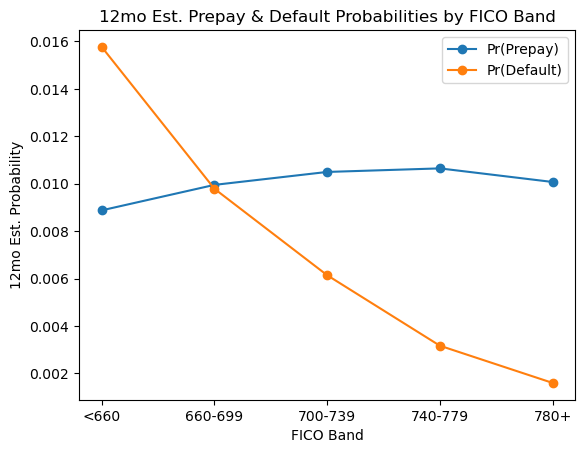

In [94]:
plt.figure()
plt.plot(
    seg_summary["fico_band"],
    seg_summary["Prepay_12m_from_Current"],
    marker="o", 
    label="Pr(Prepay)"
)
plt.plot(
    seg_summary["fico_band"],
    seg_summary["Default_12m_from_Current"],
    marker="o", 
    label="Pr(Default)"
)
plt.xlabel("FICO Band")
plt.ylabel("12mo Est. Probability")
plt.title("12mo Est. Prepay & Default Probabilities by FICO Band")

plt.legend()
plt.show()